<!-- # 02 EDA on the training data only -->

## Setup

In [1]:
# Make src/ importable and load project settings
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from stroke_prep import config

In [2]:
# Load the training file only (Canvas S4)
train = pd.read_csv(config.TRAIN_RAW)
print("shape:", train.shape)

shape: (3577, 12)


## Overview

In [3]:
# Column types and non-missing counts
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3577 entries, 0 to 3576
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3577 non-null   int64  
 1   gender             3577 non-null   str    
 2   age                3577 non-null   float64
 3   hypertension       3577 non-null   int64  
 4   heart_disease      3577 non-null   int64  
 5   ever_married       3577 non-null   str    
 6   work_type          3577 non-null   str    
 7   Residence_type     3577 non-null   str    
 8   avg_glucose_level  3577 non-null   float64
 9   bmi                3439 non-null   float64
 10  smoking_status     3577 non-null   str    
 11  stroke             3577 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 335.5 KB


In [4]:
# Summary statistics for number columns
train.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3439.000000,3577.000000
mean,36565.809337,43.165043,0.097009,0.052558,105.798088,28.898255,0.046967
std,21173.694688,22.514909,0.296011,0.223181,45.116367,7.941025,0.211597
min,67.000000,0.080000,0.000000,0.000000,55.120000,11.300000,0.000000
25%,17569.000000,25.000000,0.000000,0.000000,76.700000,23.500000,0.000000
50%,37053.000000,45.000000,0.000000,0.000000,91.650000,28.100000,0.000000
75%,54620.000000,61.000000,0.000000,0.000000,114.020000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,267.760000,97.600000,1.000000


In [5]:
# First rows
train.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,35182,Female,62.0,0,0,Yes,Govt_job,Rural,98.14,42.0,Unknown,0
1,20565,Male,13.0,0,0,No,children,Rural,85.87,24.3,Unknown,0
2,41271,Male,68.0,1,0,Yes,Govt_job,Urban,222.29,30.1,never smoked,0
3,64597,Female,33.0,0,0,Yes,Private,Rural,73.20,28.9,Unknown,0
4,50804,Male,2.0,0,0,No,children,Rural,65.84,16.1,Unknown,0


## Column groups

In [6]:
# Group columns using config.py: text, 0/1, and the remaining number columns
text_cols = config.RAW_CATEGORICAL
binary_cols = config.RAW_BINARY
number_cols = [c for c in train.columns if c not in text_cols + binary_cols + ["id"]]
print("text:", text_cols)
print("0/1:", binary_cols)
print("number:", number_cols)

text: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
0/1: ['hypertension', 'heart_disease', 'stroke']
number: ['age', 'avg_glucose_level', 'bmi']


## Chart helpers

In [7]:
# Print the counts of one column, then draw them as a bar chart
def bar_counts(col):
    counts = train[col].value_counts(dropna=False)
    print(counts)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{col}: count of each value (train)")
    ax.set_xlabel(col)
    ax.set_ylabel("rows")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [8]:
# Print the shares of one column, then draw them as a bar chart
def bar_shares(col):
    shares = train[col].value_counts(normalize=True, dropna=False)
    print(shares.round(4))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(shares.index.astype(str), shares.values)
    ax.set_title(f"{col}: share of each value (train)")
    ax.set_xlabel(col)
    ax.set_ylabel("share of rows")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [9]:
# Print summary numbers of one number column, then draw a histogram
def histogram(col):
    print(train[col].describe())
    print("missing:", int(train[col].isna().sum()))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(train[col].dropna(), bins="auto")
    ax.set_title(f"{col}: distribution (train)")
    ax.set_xlabel(col)
    ax.set_ylabel("rows")
    plt.tight_layout()
    plt.show()

## Missing values

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  138
smoking_status         0
stroke                 0
dtype: int64


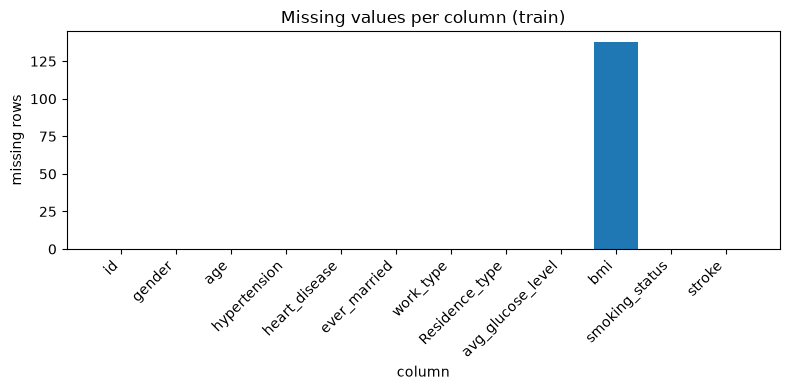

In [10]:
# Missing values per column, printed and drawn as a bar chart
missing = train.isna().sum()
print(missing)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(missing.index, missing.values)
ax.set_title("Missing values per column (train)")
ax.set_xlabel("column")
ax.set_ylabel("missing rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In train, bmi is the only column with missing values: 138 of 3,577 rows (3.9%). That's close to the 4% in the raw data, so the split kept the missing rate about the same. I handle this in D3

## Target and balancing column shares

stroke
0    0.953
1    0.047
Name: proportion, dtype: float64


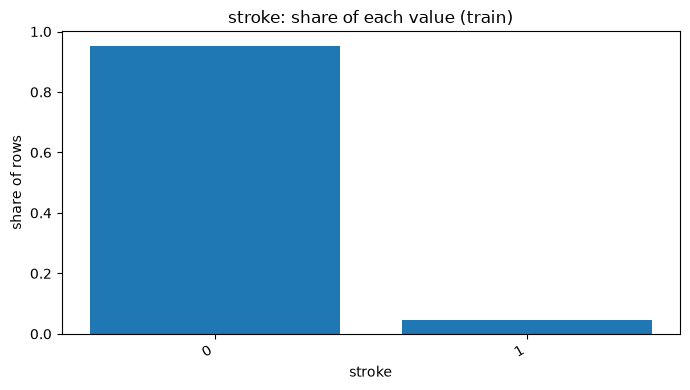

In [11]:
# Share of each stroke value
bar_shares(config.TARGET)

The target is very uneven: 95.3% of training rows have no stroke and 4.7% have one. Stroke is the label, so I leave it untouched and don't balance it.

work_type
Private          0.5706
Self-employed    0.1635
children         0.1334
Govt_job         0.1289
Never_worked     0.0036
Name: proportion, dtype: float64


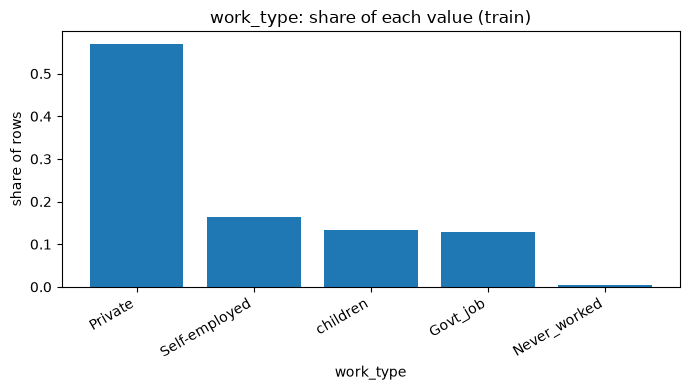

In [12]:
# Share of each work_type value
bar_shares(config.BALANCE_COL)

work_type is uneven too. Private is 57%, Self-employed 16%, children 13%, Govt_job 13%, and Never_worked only 0.36%. This imbalance is why SMOTE is applied to work_type.

## Text columns

gender
Female    2121
Male      1455
Other        1
Name: count, dtype: int64


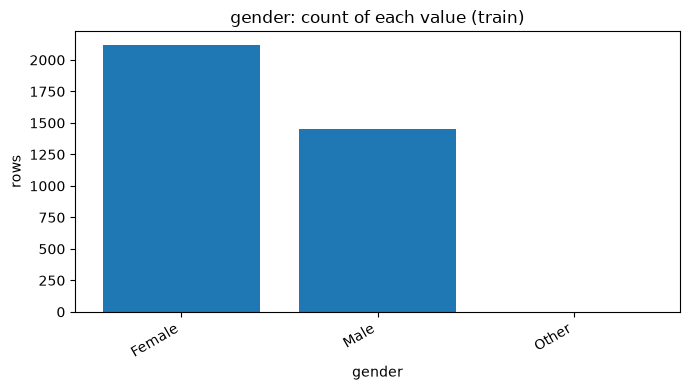

In [13]:
# Counts of each gender value
bar_counts("gender")

gender has 2,121 Female, 1,455 Male, and 1 Other. A category with one row is too small to learn from, so what to do with it is a decision I will make at the D2 Gate.

ever_married
Yes    2347
No     1230
Name: count, dtype: int64


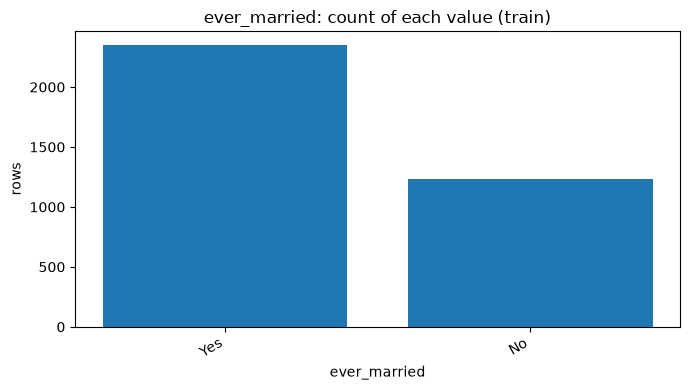

In [14]:
# Counts of each ever_married value
bar_counts("ever_married")

ever_married has 2,347 Yes and 1,230 No, with no missing values. It's a text yes/no column that needs to become a number in D4.

work_type
Private          2041
Self-employed     585
children          477
Govt_job          461
Never_worked       13
Name: count, dtype: int64


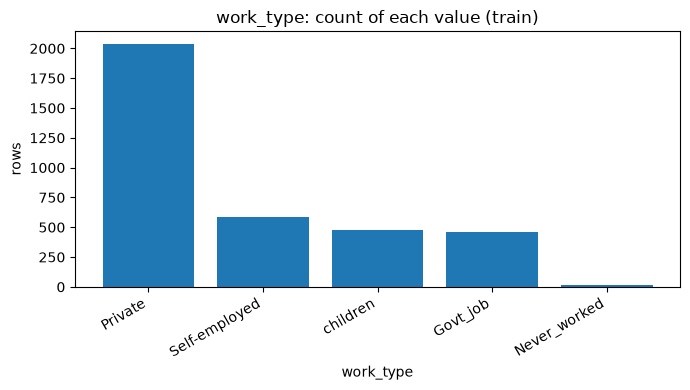

In [15]:
# Counts of each work_type value
bar_counts("work_type")

In counts, Never_worked has only 13 training rows. SMOTE builds new rows from a group's nearest neighbors, so its neighbor setting has to stay below 13. I set that in D7

Residence_type
Urban    1832
Rural    1745
Name: count, dtype: int64


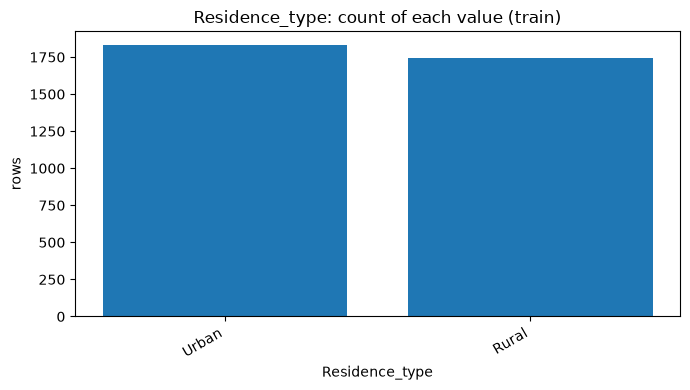

In [16]:
# Counts of each Residence_type value
bar_counts("Residence_type")

Residence_type is nearly even, with 1,832 Urban and 1,745 Rural. It has no problems besides needing encoding in D4.

smoking_status
never smoked       1328
Unknown            1082
formerly smoked     617
smokes              550
Name: count, dtype: int64


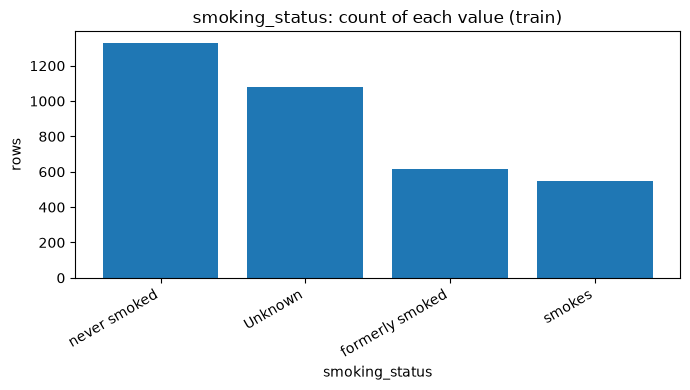

In [17]:
# Counts of each smoking_status value
bar_counts("smoking_status")

smoking_status has no blanks, but 1,082 rows (30%) are "Unknown". That's information that's really missing, just labeled. Whether to keep it as its own category or treat it as missing is a D3 decision.

## 0/1 columns

hypertension
0    3230
1     347
Name: count, dtype: int64


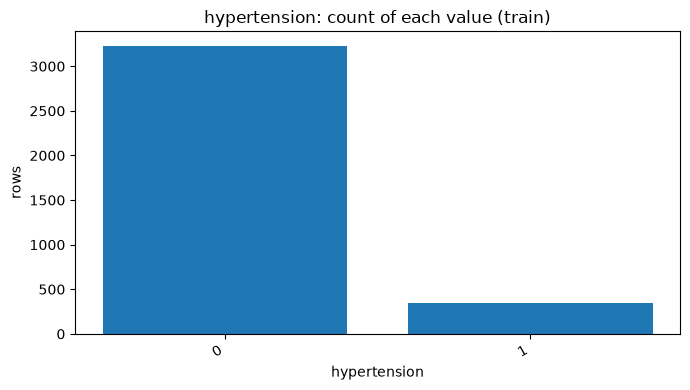

In [18]:
# Counts of each hypertension value
bar_counts("hypertension")

hypertension is already a clean 0/1 column: 347 of 3,577 have it (9.7%). It needs no fixing.

heart_disease
0    3389
1     188
Name: count, dtype: int64


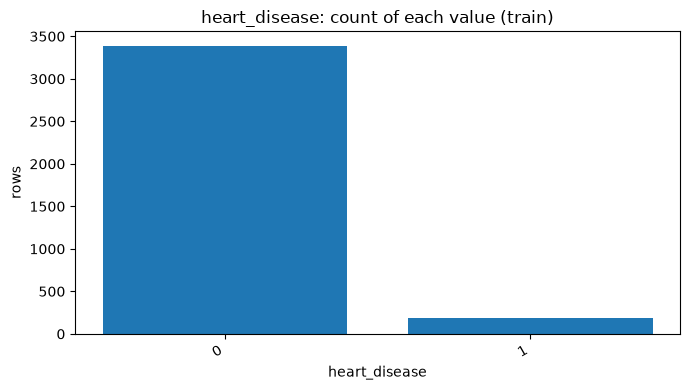

In [19]:
# Counts of each heart_disease value
bar_counts("heart_disease")

heart_disease is also a clean 0/1 column: 188 of 3,577 have it (5.3%). It needs no fixing.

stroke
0    3409
1     168
Name: count, dtype: int64


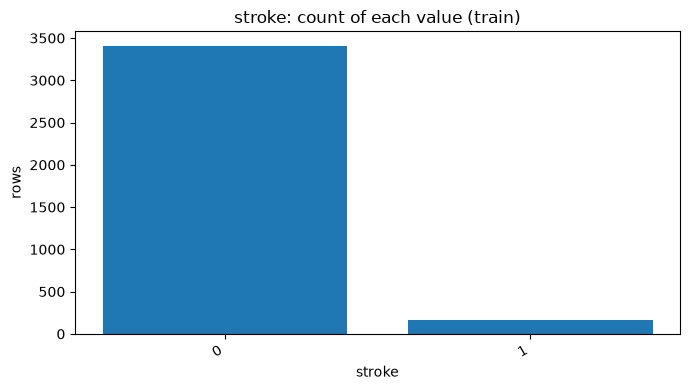

In [20]:
# Counts of each stroke value
bar_counts("stroke")

The counts match the shares above: 3,409 without a stroke and 168 with one. 168 positive cases is a small number to learn from.

## Number columns

count    3577.000000
mean       43.165043
std        22.514909
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64
missing: 0


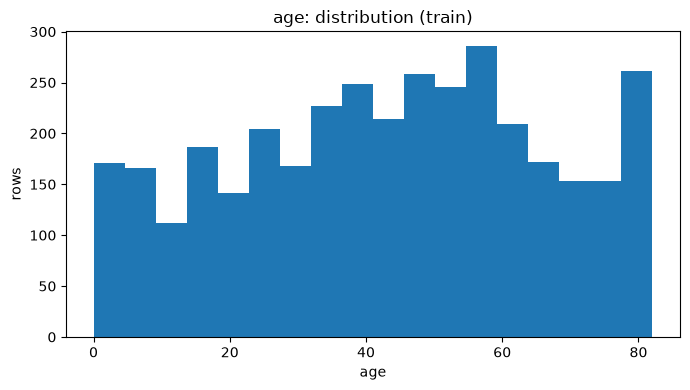

In [21]:
# Distribution of age
histogram("age")

Age runs from 0.08 to 82, with a middle value of 45. The very small values are babies recorded as fractions of a year, which fits the "children" group in work_type. Age is on a different scale than the other number columns, this is something that we will address in D5.

count    3577.000000
mean      105.798088
std        45.116367
min        55.120000
25%        76.700000
50%        91.650000
75%       114.020000
max       267.760000
Name: avg_glucose_level, dtype: float64
missing: 0


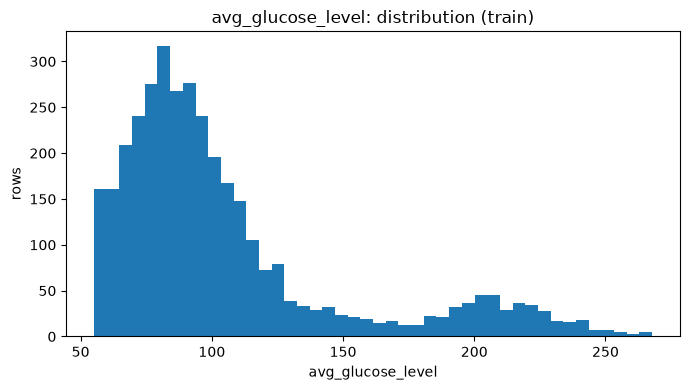

In [22]:
# Distribution of avg_glucose_level
histogram("avg_glucose_level")

avg_glucose_level has a middle value of 92 but an average of 106, and goes up to 268. The average sitting above the middle shows a long tail of high values on the right. This shape matters when choosing scaling in D5.

count    3439.000000
mean       28.898255
std         7.941025
min        11.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64
missing: 138


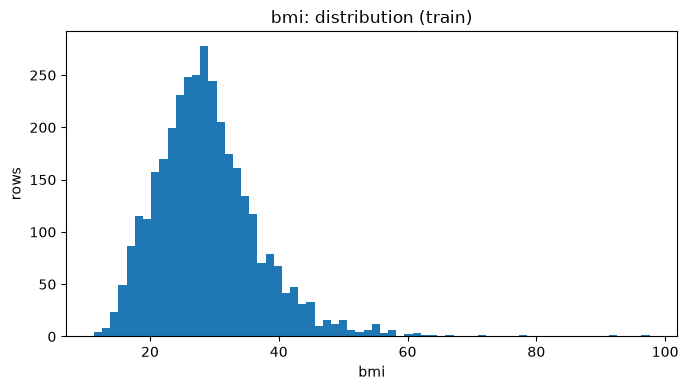

In [23]:
# Distribution of bmi
histogram("bmi")

bmi runs from 11.3 to 97.6, with a middle value of 28. The 97.6 is far from the rest and may be an outlier. bmi also has the 138 missing values from box 6. This connects to D3 (filling) and D5 (scaling).

In [24]:
# Check that every column in the groups above has a chart in this notebook
charted = {"gender", "ever_married", "work_type", "Residence_type", "smoking_status",
           "hypertension", "heart_disease", "stroke", "age", "avg_glucose_level", "bmi"}
assert set(text_cols + binary_cols + number_cols) == charted
print("every text, 0/1 and number column has a chart")

every text, 0/1 and number column has a chart


## Findings

- gender has 1 "Other" row, and the id column is only a row label. Both go to D2.
- bmi has 138 missing values (3.9%), and smoking_status has 1,082 "Unknown" (30%). Both go to D3.
- gender, ever_married, work_type, Residence_type, and smoking_status are text and need to become numbers. That's D4.
- age, avg_glucose_level, and bmi are on different scales. Glucose has a long right tail and bmi has an extreme high value. That's D5.
- Never_worked has only 13 training rows, which limits SMOTE's neighbor setting. That's D7.
- And stroke is very uneven (4.7% yes), but it's the label and stays untouched.